In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as PhuongMai
from collections import deque

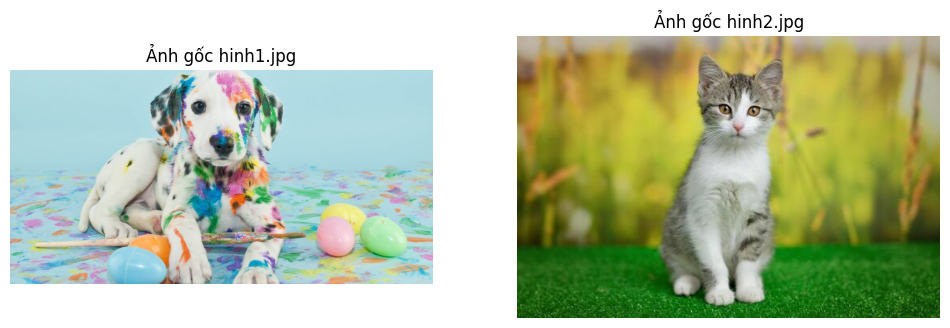

In [2]:
img = cv.imread('hinh1.jpg')
img2 = cv.imread('hinh2.jpg')

if img is None:
    raise FileNotFoundError("Không tìm thấy file 'hinh1.jpg'")
if img2 is None:
    raise FileNotFoundError("Không tìm thấy file 'hinh2.jpg'")

# Chuyển sang RGB để hiển thị đúng màu
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

# Chuyển sang ảnh xám
gray1 = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Hiển thị ảnh gốc
PhuongMai.figure(figsize=(12, 5))
PhuongMai.subplot(1, 2, 1)
PhuongMai.imshow(img_rgb)
PhuongMai.title("Ảnh gốc hinh1.jpg")
PhuongMai.axis("off")

PhuongMai.subplot(1, 2, 2)
PhuongMai.imshow(img2_rgb)
PhuongMai.title("Ảnh gốc hinh2.jpg")
PhuongMai.axis("off")
PhuongMai.show()

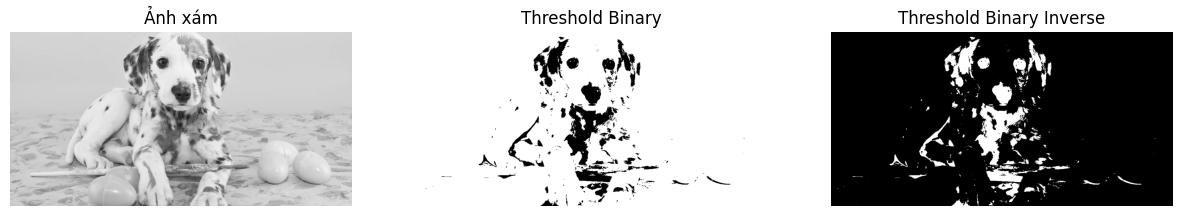

In [3]:
threshold_value = 127
_, thresh_binary = cv.threshold(gray1, threshold_value, 255, cv.THRESH_BINARY)
_, thresh_binary_inv = cv.threshold(gray1, threshold_value, 255, cv.THRESH_BINARY_INV)

PhuongMai.figure(figsize=(15, 5))
PhuongMai.subplot(1, 3, 1)
PhuongMai.imshow(gray1, cmap='gray')
PhuongMai.title("Ảnh xám")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 2)
PhuongMai.imshow(thresh_binary, cmap='gray')
PhuongMai.title("Threshold Binary")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 3)
PhuongMai.imshow(thresh_binary_inv, cmap='gray')
PhuongMai.title("Threshold Binary Inverse")
PhuongMai.axis("off")
PhuongMai.show()

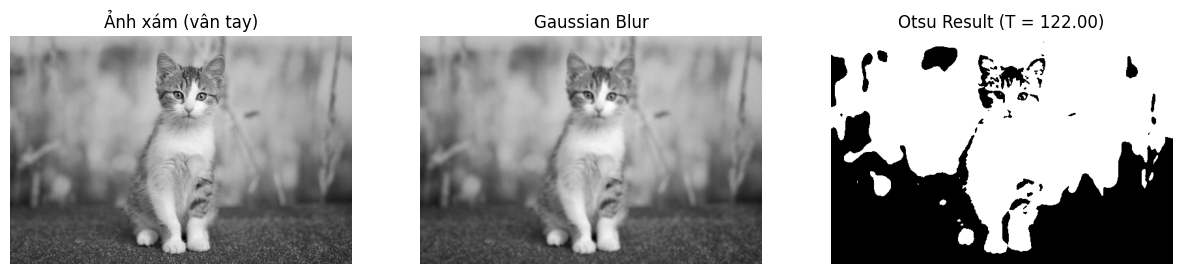

In [4]:
blur_otsu = cv.GaussianBlur(gray2, (5, 5), 0)
otsu_thresh_value, otsu_result = cv.threshold(
    blur_otsu, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

PhuongMai.figure(figsize=(15, 5))
PhuongMai.subplot(1, 3, 1)
PhuongMai.imshow(gray2, cmap='gray')
PhuongMai.title("Ảnh xám (vân tay)")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 2)
PhuongMai.imshow(blur_otsu, cmap='gray')
PhuongMai.title("Gaussian Blur")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 3)
PhuongMai.imshow(otsu_result, cmap='gray')
PhuongMai.title(f"Otsu Result (T = {otsu_thresh_value:.2f})")
PhuongMai.axis("off")
PhuongMai.show()

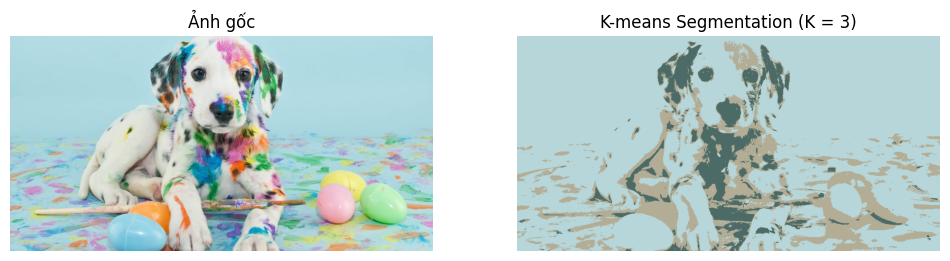

In [5]:
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3
_, labels, centers = cv.kmeans(
    pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

PhuongMai.figure(figsize=(12, 5))
PhuongMai.subplot(1, 2, 1)
PhuongMai.imshow(img_rgb)
PhuongMai.title("Ảnh gốc")
PhuongMai.axis("off")

PhuongMai.subplot(1, 2, 2)
PhuongMai.imshow(segmented_image)
PhuongMai.title(f"K-means Segmentation (K = {k})")
PhuongMai.axis("off")
PhuongMai.show()

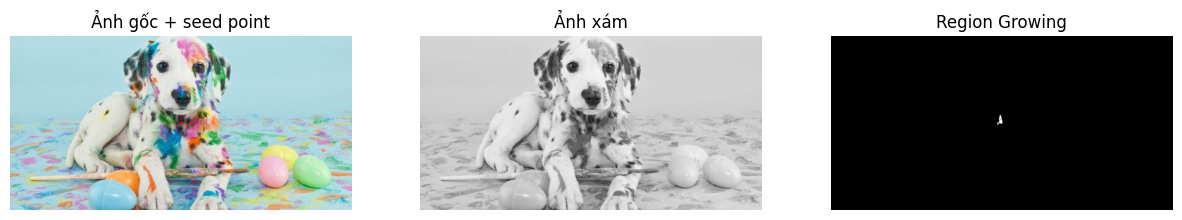

In [6]:
def region_growing(image, seed, threshold=10):
    rows, cols = image.shape
    segmented = np.zeros((rows, cols), dtype=np.uint8)
    visited = np.zeros((rows, cols), dtype=bool)

    seed_value = int(image[seed[1], seed[0]])
    q = deque()
    q.append((seed[1], seed[0]))
    visited[seed[1], seed[0]] = True

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while q:
        r, c = q.popleft()
        segmented[r, c] = 255

        for dr, dc in directions:
            nr, nc = r + dr, c + dc

            if 0 <= nr < rows and 0 <= nc < cols and not visited[nr, nc]:
                visited[nr, nc] = True
                if abs(int(image[nr, nc]) - seed_value) <= threshold:
                    q.append((nr, nc))

    return segmented

# Chọn seed ở giữa ảnh
seed_point = (gray1.shape[1] // 2, gray1.shape[0] // 2)
region_result = region_growing(gray1, seed_point, threshold=15)

# Vẽ seed point lên ảnh để dễ nhìn
img_seed = img_rgb.copy()
cv.circle(img_seed, seed_point, 5, (255, 0, 0), -1)

PhuongMai.figure(figsize=(15, 5))
PhuongMai.subplot(1, 3, 1)
PhuongMai.imshow(img_seed)
PhuongMai.title("Ảnh gốc + seed point")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 2)
PhuongMai.imshow(gray1, cmap='gray')
PhuongMai.title("Ảnh xám")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 3)
PhuongMai.imshow(region_result, cmap='gray')
PhuongMai.title("Region Growing")
PhuongMai.axis("off")
PhuongMai.show()

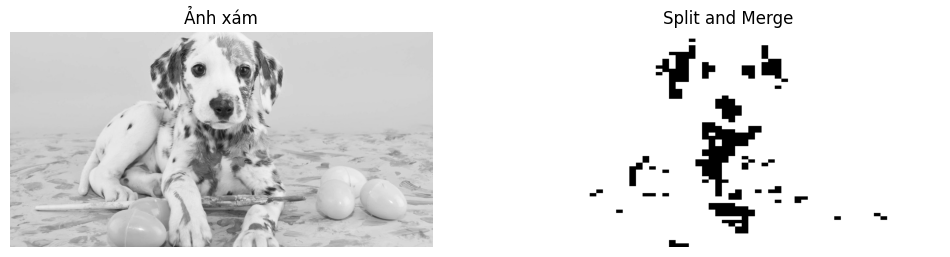

In [8]:
# =========================
# 5. Sử dụng thuật toán Split and Merge để phân đoạn ảnh
# =========================
def split_merge(image, min_size=16, std_threshold=10):
    result = np.zeros_like(image)

    def recursive_split(x, y, w, h):
        region = image[y:y+h, x:x+w]

        if w <= min_size or h <= min_size or np.std(region) < std_threshold:
            mean_val = np.mean(region)
            result[y:y+h, x:x+w] = 255 if mean_val > 127 else 0
            return

        w2 = w // 2
        h2 = h // 2

        recursive_split(x, y, w2, h2)
        recursive_split(x + w2, y, w - w2, h2)
        recursive_split(x, y + h2, w2, h - h2)
        recursive_split(x + w2, y + h2, w - w2, h - h2)

    h, w = image.shape
    recursive_split(0, 0, w, h)
    return result

split_merge_result = split_merge(gray1, min_size=16, std_threshold=12)

PhuongMai.figure(figsize=(12, 5))
PhuongMai.subplot(1, 2, 1)
PhuongMai.imshow(gray1, cmap='gray')
PhuongMai.title("Ảnh xám")
PhuongMai.axis("off")

PhuongMai.subplot(1, 2, 2)
PhuongMai.imshow(split_merge_result, cmap='gray')
PhuongMai.title("Split and Merge")
PhuongMai.axis("off")
PhuongMai.show()

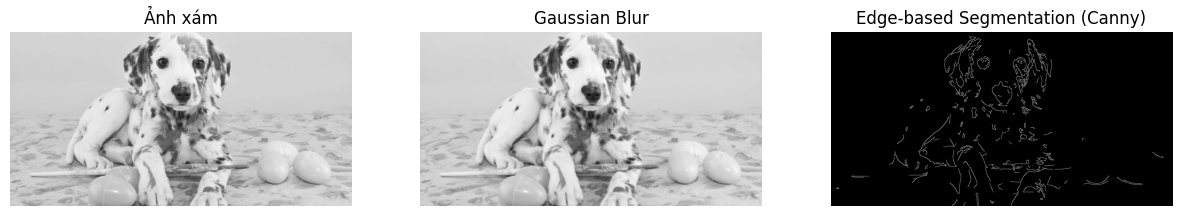

In [9]:
# =========================
# 6. Phân đoạn ảnh với Edge-based segmentation
# =========================
blur_edge = cv.GaussianBlur(gray1, (5, 5), 0)
edges = cv.Canny(blur_edge, 100, 200)

PhuongMai.figure(figsize=(15, 5))
PhuongMai.subplot(1, 3, 1)
PhuongMai.imshow(gray1, cmap='gray')
PhuongMai.title("Ảnh xám")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 2)
PhuongMai.imshow(blur_edge, cmap='gray')
PhuongMai.title("Gaussian Blur")
PhuongMai.axis("off")

PhuongMai.subplot(1, 3, 3)
PhuongMai.imshow(edges, cmap='gray')
PhuongMai.title("Edge-based Segmentation (Canny)")
PhuongMai.axis("off")
PhuongMai.show()